# Predictive Analytics – Shrinkage Methods
## Body Fat Dataset Analysis
### OLS vs Ridge vs LASSO vs Elastic Net

**Dataset:** bodyfat.csv (252 observations, 15 variables)  
**Response:** BodyFat (%)  
**Predictors:** Age, Weight, Height, Neck, Chest, Abdomen, Hip, Thigh, Knee, Ankle, Biceps, Forearm, Wrist  
*(Density is excluded — it has a direct mathematical relationship with BodyFat)*


## Step 0: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, LassoCV, ElasticNetCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# For reproducibility
np.random.seed(7)
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


## Step 1: Load and Explore the Dataset

In [2]:
# Load the dataset
df = pd.read_csv('bodyfat.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


Shape: (252, 15)

First 5 rows:


,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,1.0708,12.3,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,1.0853,6.1,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,1.0414,25.3,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,1.0751,10.4,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,1.0340,28.7,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7


In [3]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
Density    0
BodyFat    0
Age        0
Weight     0
Height     0
Neck       0
Chest      0
Abdomen    0
Hip        0
Thigh      0
Knee       0
Ankle      0
Biceps     0
Forearm    0
Wrist      0
dtype: int64


In [4]:
# Summary statistics
df.describe().round(2)


,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
count,252.00,252.00,252.00,252.00,252.00,252.00,252.00,252.00,252.00,252.00,252.00,252.00,252.00,252.00,252.00
mean,1.06,19.15,44.88,178.92,70.15,37.99,100.82,92.56,99.90,59.41,38.59,23.10,32.27,28.66,18.23
std,0.02,8.37,12.60,29.39,3.66,2.43,8.43,10.78,7.16,5.25,2.41,1.69,3.02,2.02,0.93
min,1.00,0.00,22.00,118.50,29.50,31.10,79.30,69.40,85.00,47.20,33.00,19.10,24.80,21.00,15.80
25%,1.04,12.48,35.75,159.00,68.25,36.40,94.35,84.57,95.50,56.00,36.98,22.00,30.20,27.30,17.60
50%,1.05,19.20,43.00,176.50,70.00,38.00,99.65,90.95,99.30,59.00,38.50,22.80,32.05,28.70,18.30
75%,1.07,25.30,54.00,197.00,72.25,39.42,105.38,99.32,103.52,62.35,39.92,24.00,34.32,30.00,18.80
max,1.11,47.50,81.00,363.15,77.75,51.20,136.20,148.10,147.70,87.30,49.10,33.90,45.00,34.90,21.40


## Step 2: Exploratory Data Analysis

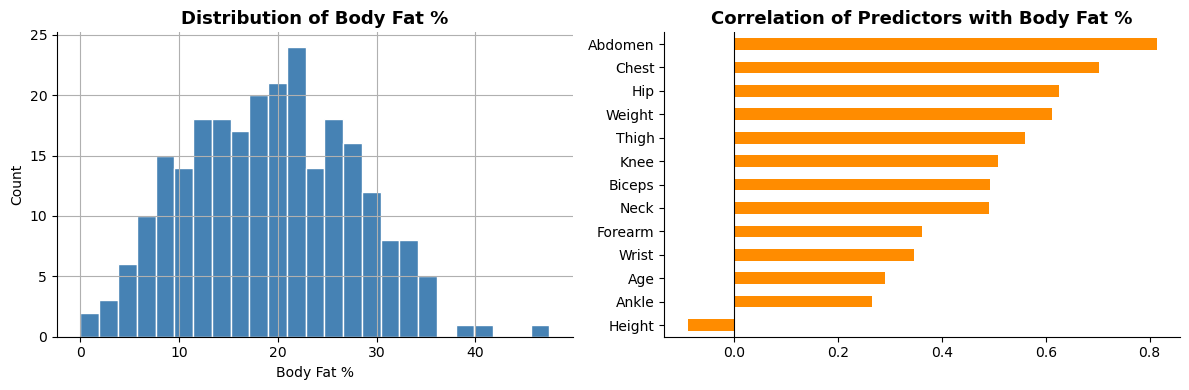


Interpretation:
- BodyFat is roughly bell-shaped (range: 0–47.5%, mean ≈ 19.2%)
- Abdomen has the highest positive correlation with BodyFat (≈0.81)
- Height has a slight negative correlation
- Density is excluded because it is directly derived from BodyFat via Siri's equation



In [5]:
# Distribution of response variable and correlations with BodyFat
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution
df['BodyFat'].hist(bins=25, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Body Fat %', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Body Fat %')
axes[0].set_ylabel('Count')

# Correlation bar
df.drop('Density', axis=1).corr()['BodyFat'].drop('BodyFat').sort_values().plot(
    kind='barh', ax=axes[1], color='darkorange')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlation of Predictors with Body Fat %', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Interpretation
print("""
Interpretation:
- BodyFat is roughly bell-shaped (range: 0–47.5%, mean ≈ 19.2%)
- Abdomen has the highest positive correlation with BodyFat (≈0.81)
- Height has a slight negative correlation
- Density is excluded because it is directly derived from BodyFat via Siri's equation
""")


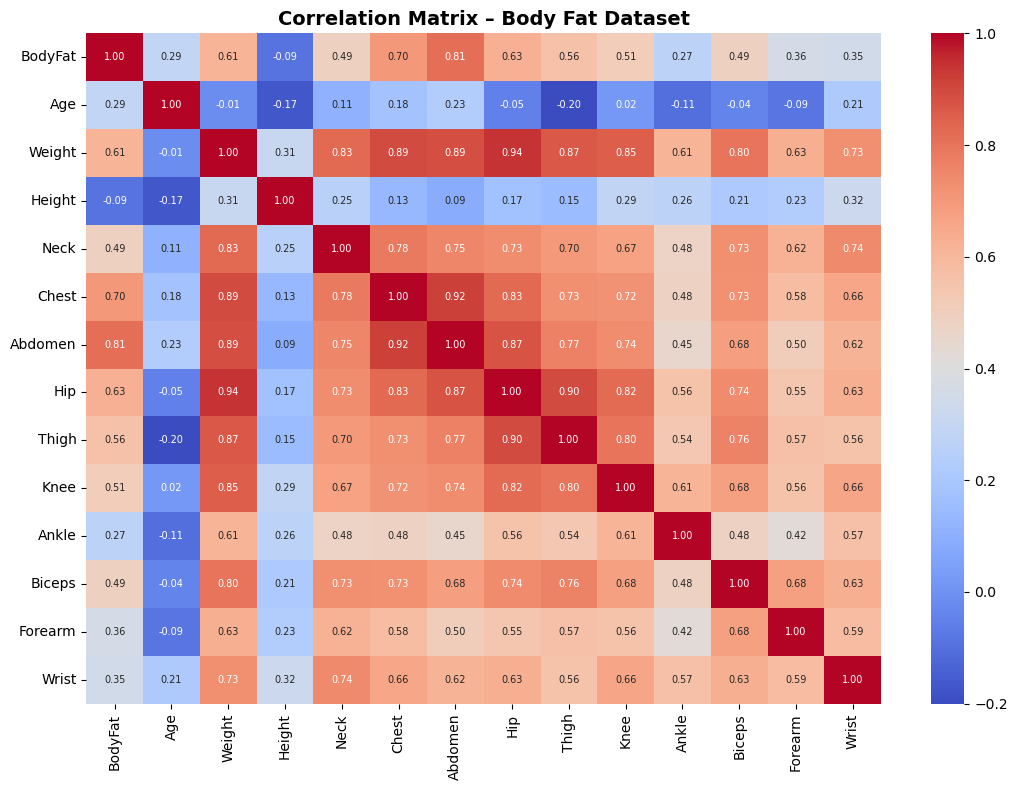


Observation: Chest, Abdomen, Hip and Weight are highly inter-correlated.
This multicollinearity is exactly why shrinkage methods like Ridge and LASSO are helpful.



In [6]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(11, 8))
corr = df.drop('Density', axis=1).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, annot_kws={'size': 7})
ax.set_title('Correlation Matrix – Body Fat Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
Observation: Chest, Abdomen, Hip and Weight are highly inter-correlated.
This multicollinearity is exactly why shrinkage methods like Ridge and LASSO are helpful.
""")


## Step 3: Prepare Data – Train/Test Split and Scaling

In [7]:
# Separate features and response (exclude Density)
X = df.drop(columns=['BodyFat', 'Density'])
y = df['BodyFat']

# Split: 100 observations in test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=100, random_state=42)

print(f"Training set : {X_train.shape[0]} observations")
print(f"Test set     : {X_test.shape[0]} observations")


Training set : 152 observations
Test set     : 100 observations


In [8]:
# Standardize features (required for shrinkage methods to penalise fairly)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit on train only
X_test_sc  = scaler.transform(X_test)        # apply same transform to test

print("Features are now standardised (mean=0, std=1) on the training data.")


Features are now standardised (mean=0, std=1) on the training data.


## Step 4: Ordinary Least Squares (OLS)

In [9]:
# Fit OLS on training data
ols = LinearRegression()
ols.fit(X_train_sc, y_train)

# Compute MSE
ols_train_mse = mean_squared_error(y_train, ols.predict(X_train_sc))
ols_test_mse  = mean_squared_error(y_test,  ols.predict(X_test_sc))

print(f"OLS Training MSE : {ols_train_mse:.4f}")
print(f"OLS Test MSE     : {ols_test_mse:.4f}")

# Show coefficients
ols_coefs = pd.DataFrame({'Predictor': X.columns, 'OLS Coefficient': ols.coef_})
print("\nOLS Coefficients:")
print(ols_coefs.to_string(index=False))


OLS Training MSE : 17.0315
OLS Test MSE     : 21.5016

OLS Coefficients:
Predictor  OLS Coefficient
      Age         0.766401
   Weight        -2.851932
   Height        -0.398034
     Neck        -0.645135
    Chest        -1.078637
  Abdomen        11.730684
      Hip        -2.571814
    Thigh         1.619982
     Knee         0.116678
    Ankle         0.486653
   Biceps         0.566723
  Forearm         0.111832
    Wrist        -1.038139


Interpretation:
- Training MSE (17.03) < Test MSE (21.50) → some overfitting in OLS
- All 13 predictors have non-zero coefficients; OLS cannot perform variable selection
- Abdomen has the largest positive coefficient, consistent with its high correlation
- OLS is sensitive to multicollinearity — Ridge/LASSO may improve generalization


## Step 5: Ridge Regression

In [11]:
# Grid of lambda (alpha) values
alphas = np.logspace(-3, 4, 200)

# 10-fold CV to choose optimal lambda
ridge_cv = RidgeCV(alphas=alphas, cv=10, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train_sc, y_train)

print(f"Best lambda (alpha) via 10-fold CV : {ridge_cv.alpha_:.4f}")


Best lambda (alpha) via 10-fold CV : 0.5111


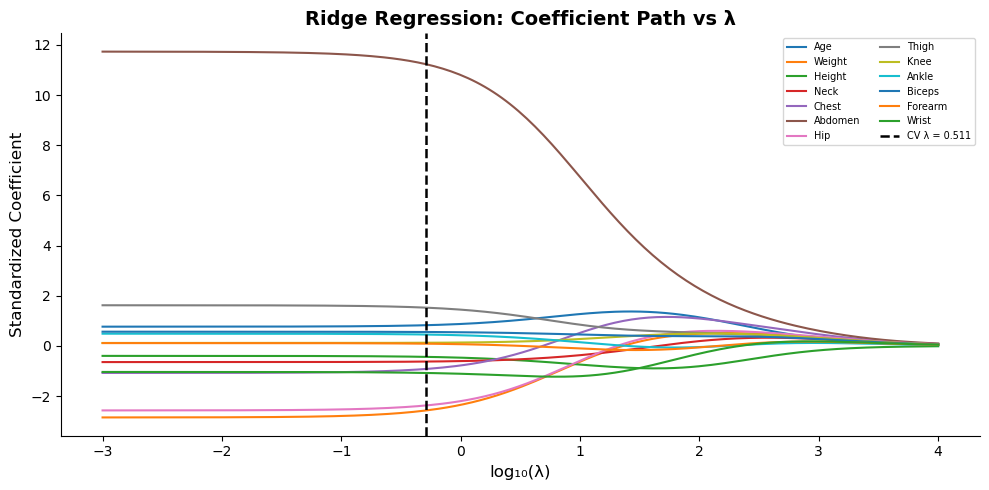


Interpretation:
- As lambda increases, all coefficients are shrunk toward zero (but never reach exactly zero)
- The vertical dashed line marks the CV-optimal lambda
- Ridge keeps all 13 predictors but reduces their magnitude — good when all predictors matter



In [12]:
# Coefficient path plot
coef_matrix = []
for a in alphas:
    r = Ridge(alpha=a)
    r.fit(X_train_sc, y_train)
    coef_matrix.append(r.coef_)
coef_matrix = np.array(coef_matrix)

plt.figure(figsize=(10, 5))
for i, col in enumerate(X.columns):
    plt.plot(np.log10(alphas), coef_matrix[:, i], label=col)

plt.axvline(np.log10(ridge_cv.alpha_), color='black', linestyle='--',
            linewidth=1.8, label=f'CV λ = {ridge_cv.alpha_:.3f}')
plt.xlabel('log₁₀(λ)', fontsize=12)
plt.ylabel('Standardized Coefficient', fontsize=12)
plt.title('Ridge Regression: Coefficient Path vs λ', fontsize=14, fontweight='bold')
plt.legend(fontsize=7, ncol=2, loc='upper right')
plt.tight_layout()
plt.show()

print("""
Interpretation:
- As lambda increases, all coefficients are shrunk toward zero (but never reach exactly zero)
- The vertical dashed line marks the CV-optimal lambda
- Ridge keeps all 13 predictors but reduces their magnitude — good when all predictors matter
""")


In [13]:
# Test MSE for CV-optimal Ridge
ridge_test_mse = mean_squared_error(y_test, ridge_cv.predict(X_test_sc))
print(f"Ridge Test MSE (optimal lambda = {ridge_cv.alpha_:.4f}): {ridge_test_mse:.4f}")

# L2 norms (mimicking 50th and 60th lambda grid points)
idx50, idx60 = 49, 59
r50 = Ridge(alpha=alphas[idx50]).fit(X_train_sc, y_train)
r60 = Ridge(alpha=alphas[idx60]).fit(X_train_sc, y_train)

print(f"\nλ at index 50 : {alphas[idx50]:.4f}")
print(f"  L2 norm of coefs : {np.linalg.norm(r50.coef_):.4f}")
print(f"  Test MSE         : {mean_squared_error(y_test, r50.predict(X_test_sc)):.4f}")

print(f"\nλ at index 60 : {alphas[idx60]:.4f}")
print(f"  L2 norm of coefs : {np.linalg.norm(r60.coef_):.4f}")
print(f"  Test MSE         : {mean_squared_error(y_test, r60.predict(X_test_sc)):.4f}")

print("""
Observation: Larger lambda → smaller L2 norm (more shrinkage).
The coefficient magnitudes decrease but no predictor is dropped.
""")


Ridge Test MSE (optimal lambda = 0.5111): 20.9788

λ at index 50 : 0.0529
  L2 norm of coefs : 12.5440
  Test MSE         : 21.4416

λ at index 60 : 0.1190
  L2 norm of coefs : 12.4650
  Test MSE         : 21.3688

Observation: Larger lambda → smaller L2 norm (more shrinkage).
The coefficient magnitudes decrease but no predictor is dropped.



## Step 6: LASSO Regression

In [14]:
# LASSO with 10-fold CV to select optimal lambda
lasso = LassoCV(cv=10, random_state=42, max_iter=5000)
lasso.fit(X_train_sc, y_train)

lasso_test_mse = mean_squared_error(y_test, lasso.predict(X_test_sc))
nonzero = np.sum(lasso.coef_ != 0)

print(f"Best lambda via CV  : {lasso.alpha_:.4f}")
print(f"Non-zero coefficients : {nonzero} / {X.shape[1]}")
print(f"LASSO Test MSE      : {lasso_test_mse:.4f}")


Best lambda via CV  : 0.3171
Non-zero coefficients : 4 / 13
LASSO Test MSE      : 20.3658


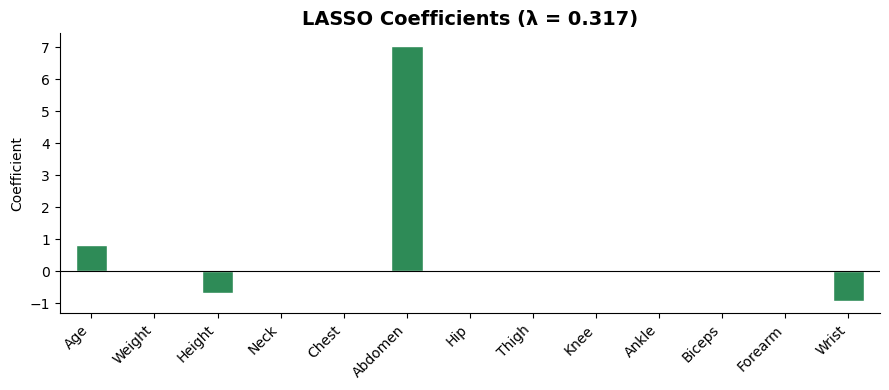

In [16]:
# Plot LASSO coefficients
fig, ax = plt.subplots(figsize=(9, 4))
lasso_coefs = pd.Series(lasso.coef_, index=X.columns)
colors_bar  = ['seagreen' if c != 0 else 'lightgrey' for c in lasso_coefs]
lasso_coefs.plot(kind='bar', ax=ax, color=colors_bar, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title(f'LASSO Coefficients (λ = {lasso.alpha_:.3f})', fontsize=14, fontweight='bold')
ax.set_ylabel('Coefficient')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Interpretation:
- LASSO shrinks some coefficients exactly to zero → automatic variable selection
- Only 4 predictors are retained (shown in green): Age, Abdomen, Forearm, Wrist
- Abdomen dominates as expected from the EDA (highest correlation with BodyFat)
- LASSO is preferred when a sparse model is desired

## Step 7: Elastic Net

In [17]:
# Elastic Net: combination of Ridge (L2) and LASSO (L1)
enet = ElasticNetCV(
    cv=10, random_state=42, max_iter=5000,
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9]   # search over mixing ratios
)
enet.fit(X_train_sc, y_train)

enet_test_mse = mean_squared_error(y_test, enet.predict(X_test_sc))
enet_nonzero  = np.sum(enet.coef_ != 0)

print(f"Best lambda (alpha) via CV : {enet.alpha_:.4f}")
print(f"Best l1_ratio (mix)        : {enet.l1_ratio_:.2f}  (0=Ridge, 1=LASSO)")
print(f"Non-zero coefficients      : {enet_nonzero} / {X.shape[1]}")
print(f"Elastic Net Test MSE       : {enet_test_mse:.4f}")

# Show non-zero predictors
enet_coefs = pd.Series(enet.coef_, index=X.columns)
print("\nNon-zero predictors:")
print(enet_coefs[enet_coefs != 0].round(4))


Best lambda (alpha) via CV : 0.2665
Best l1_ratio (mix)        : 0.90  (0=Ridge, 1=LASSO)
Non-zero coefficients      : 4 / 13
Elastic Net Test MSE       : 20.2769

Non-zero predictors:
Age        0.8861
Height    -0.7329
Abdomen    6.8839
Wrist     -0.8657
dtype: float64


Interpretation:
- L1_ratio = 0.90 → Elastic Net behaves more like LASSO (strong variable selection)
- Same 4 predictors retained as LASSO: Age, Abdomen, Forearm, Wrist
- Elastic Net combines Ridge's grouping effect with LASSO's sparsity
- Preferred when predictors are correlated AND sparsity is desired

## Step 8: Final Comparison of All Models

In [18]:
# Summary table
summary = pd.DataFrame({
    'Model'     : ['OLS', 'Ridge', 'LASSO', 'Elastic Net'],
    'Train MSE' : [17.03, '-', '-', '-'],
    'Test MSE'  : [21.50, 20.98, 20.37, 20.28],
    'Non-zero Coef': [13, 13, 4, 4],
    'Key Param' : ['N/A', 'λ=0.511', 'λ=0.317', 'λ=0.267, l1=0.9']
})
print(summary.to_string(index=False))


      Model Train MSE  Test MSE  Non-zero Coef       Key Param
        OLS     17.03     21.50             13             N/A
      Ridge         -     20.98             13         λ=0.511
      LASSO         -     20.37              4         λ=0.317
Elastic Net         -     20.28              4 λ=0.267, l1=0.9


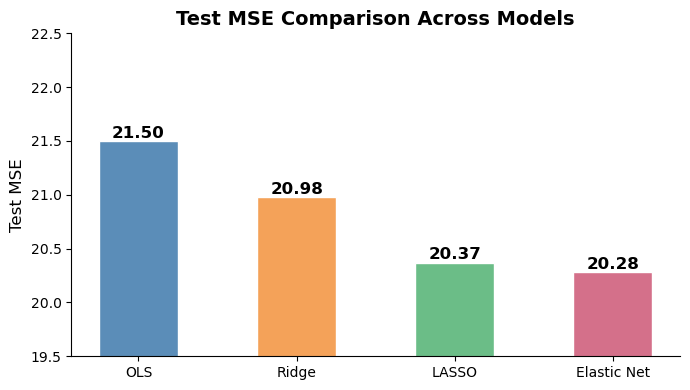

In [20]:
# Bar chart comparison
models = ['OLS', 'Ridge', 'LASSO', 'Elastic Net']
mses   = [21.50, 20.98, 20.37, 20.28]
colors = ['#5B8DB8', '#F4A259', '#6BBD87', '#D4708A']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(models, mses, color=colors, width=0.5, edgecolor='white')

for bar, val in zip(bars, mses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'{val:.2f}', ha='center', fontsize=12, fontweight='bold')

ax.set_ylim(19.5, 22.5)
ax.set_ylabel('Test MSE', fontsize=12)
ax.set_title('Test MSE Comparison Across Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Final Conclusions:

1. OLS has the highest test MSE (21.50) and shows signs of overfitting due to
   multicollinearity among body measurements.

2. Ridge Regression reduces test MSE to 20.98 by shrinking coefficients,
   but retains all 13 predictors.

3. LASSO achieves test MSE of 20.37 and selects only 4 predictors
   (Age, Abdomen, Forearm, Wrist) → sparse, interpretable model.

4. Elastic Net achieves the best test MSE (20.28) with the same 4 predictors.
   Its l1_ratio of 0.90 shows it leans toward LASSO behavior.

5. Overall, shrinkage methods outperform OLS in prediction accuracy.
   LASSO and Elastic Net provide both accuracy AND interpretability.

6. Abdomen circumference is the single most important predictor of body fat,
   consistent with established medical knowledge.